In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('student_performance.csv')

In [43]:
df.head()

,Student_ID,Name,Age,Program,Python,Mathematics,Statistics,Machine_Learning,Attendance
0,S001,Ali Khan,20,AI,85,78,92,88,95
1,S002,Sara Ahmed,21,AI,72,75,70,80,90
2,S003,Ahmed Raza,22,SE,90,88,91,93,96
3,S004,Fatima Noor,20,DS,65,70,68,72,85
4,S005,Usman Ali,21,AI,78,82,80,76,88


Checking Missing values

In [44]:
df.isnull().sum()

Student_ID          0
Name                0
Age                 0
Program             0
Python              0
Mathematics         0
Statistics          0
Machine_Learning    0
Attendance          0
dtype: int64

Duplicate Values removed

In [45]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


Renaming columns

In [46]:
df = df.rename(columns={ "Machine_Learning": "ML_Marks", "Attendance": "Attendance_Percent" })
df.columns

Index(['Student_ID', 'Name', 'Age', 'Program', 'Python', 'Mathematics',
       'Statistics', 'ML_Marks', 'Attendance_Percent'],
      dtype='object')

Create an avg_score column

In [47]:
SUBJECTS = ["Python", "Mathematics", "Statistics", "ML_Marks"]

df["Average_Score"] = np.round(df[SUBJECTS].mean(axis=1), 2)
df.head()

,Student_ID,Name,Age,Program,Python,Mathematics,Statistics,ML_Marks,Attendance_Percent,Average_Score
0,S001,Ali Khan,20,AI,85,78,92,88,95,85.75
1,S002,Sara Ahmed,21,AI,72,75,70,80,90,74.25
2,S003,Ahmed Raza,22,SE,90,88,91,93,96,90.50
3,S004,Fatima Noor,20,DS,65,70,68,72,85,68.75
4,S005,Usman Ali,21,AI,78,82,80,76,88,79.00


Create Performance category

In [48]:
def classify_performance(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"

df["Performance"] = df["Average_Score"].apply(classify_performance)
df[["Student_ID", "Name", "Average_Score", "Performance"]].head(10)

,Student_ID,Name,Average_Score,Performance
0,S001,Ali Khan,85.75,Good
1,S002,Sara Ahmed,74.25,Average
2,S003,Ahmed Raza,90.50,Excellent
3,S004,Fatima Noor,68.75,Needs Improvement
4,S005,Usman Ali,79.00,Average
5,S006,Ayesha Malik,95.50,Excellent
6,S007,Hassan Tariq,58.75,Needs Improvement
7,S008,Zainab Iqbal,88.75,Good
8,S009,Bilal Ahmed,76.00,Average
9,S010,Maryam Khan,82.25,Good


Save CSV

In [49]:
df.to_csv("cleaned_studentperformance.csv", index=False)
print("Saved: cleaned_studentperformance.csv")

Saved: cleaned_studentperformance.csv


Visualizations

Bar chart: average marks of each student

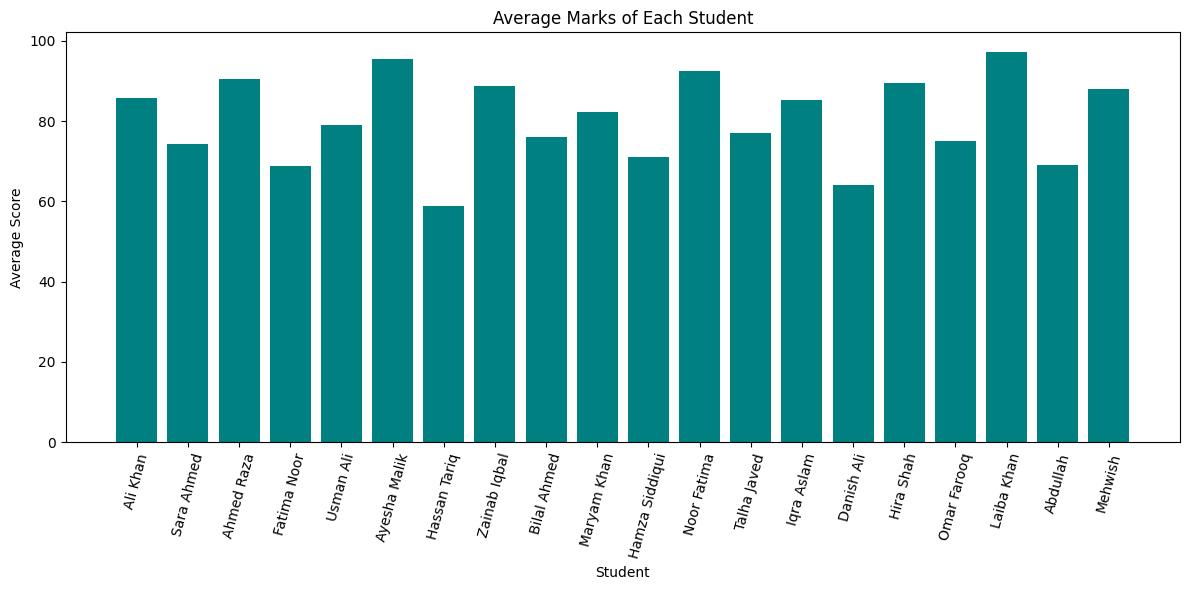

In [50]:
plt.figure(figsize=(12, 6))
plt.bar(df["Name"], df["Average_Score"], color="teal")
plt.title("Average Marks of Each Student")
plt.xlabel("Student")
plt.ylabel("Average Score")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Histogram: distribution of Average Scores

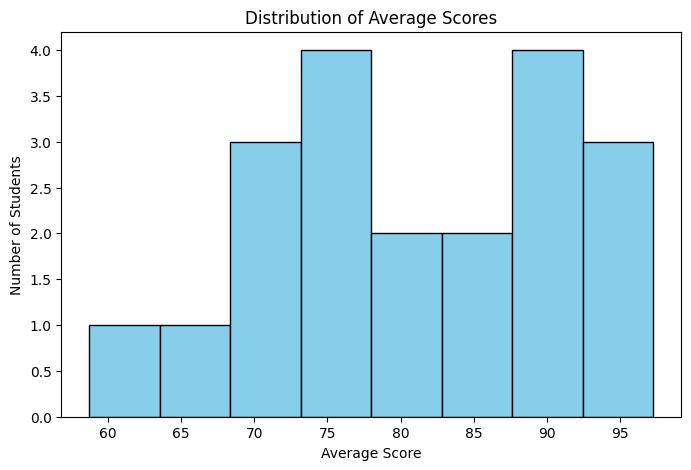

In [51]:
plt.figure(figsize=(8, 5))
plt.hist(df["Average_Score"], bins=8, color="skyblue", edgecolor="black")
plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.show()

Scatter plot: Python vs Machine Learning marks

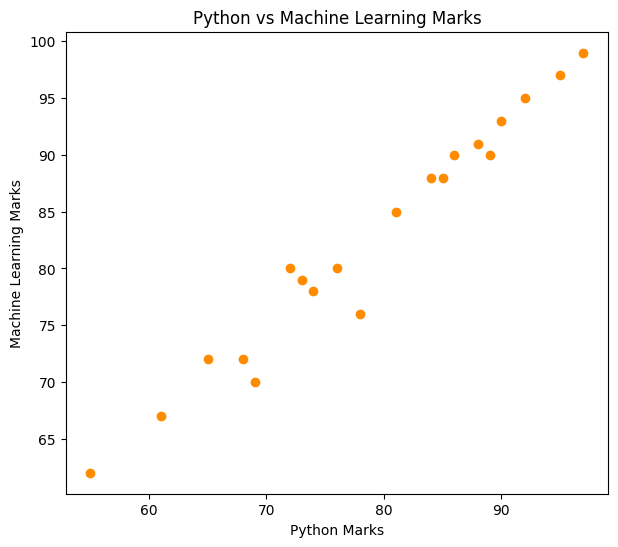

In [52]:
plt.figure(figsize=(7, 6))
plt.scatter(df["Python"], df["ML_Marks"], color="darkorange")
plt.title("Python vs Machine Learning Marks")
plt.xlabel("Python Marks")
plt.ylabel("Machine Learning Marks")
plt.show()

Pie chart: distribution by Performance category

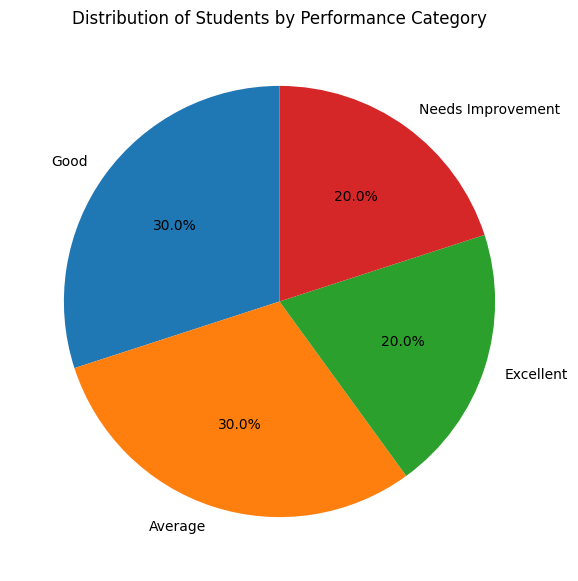

In [53]:
performance_counts = df["Performance"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(performance_counts, labels=performance_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Students by Performance Category")
plt.show()

Box plot: spread of marks across all subjects

<Figure size 900x600 with 0 Axes>

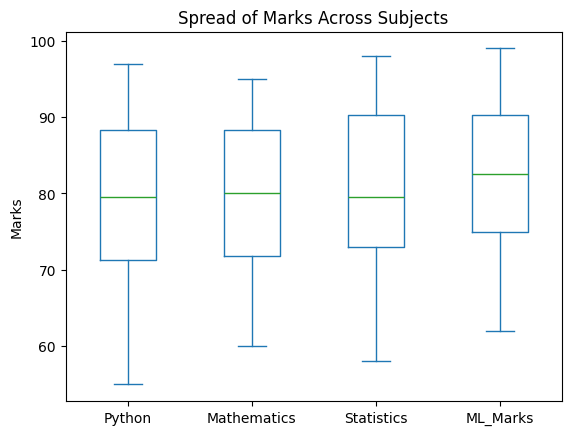

In [54]:
plt.figure(figsize=(9, 6))
df[["Python", "Mathematics", "Statistics", "ML_Marks"]].plot(kind="box")
plt.title("Spread of Marks Across Subjects")
plt.ylabel("Marks")
plt.show()

Student Dashboard

How many students are in the dataset?

In [55]:
total_students = df["Student_ID"].nunique()
print(f"Total number of students: {total_students}")

Total number of students: 20


Average score for each subject

In [56]:
subject_averages = df[SUBJECTS].mean().round(2)
print("Average marks per subject:\n")
print(subject_averages)

Average marks per subject:

Python         78.9
Mathematics    79.5
Statistics     80.6
ML_Marks       82.6
dtype: float64


In [57]:
df["Average_Score"] = np.round(df[SUBJECTS].mean(axis=1), 2)
df.head()

,Student_ID,Name,Age,Program,Python,Mathematics,Statistics,ML_Marks,Attendance_Percent,Average_Score,Performance
0,S001,Ali Khan,20,AI,85,78,92,88,95,85.75,Good
1,S002,Sara Ahmed,21,AI,72,75,70,80,90,74.25,Average
2,S003,Ahmed Raza,22,SE,90,88,91,93,96,90.50,Excellent
3,S004,Fatima Noor,20,DS,65,70,68,72,85,68.75,Needs Improvement
4,S005,Usman Ali,21,AI,78,82,80,76,88,79.00,Average


Top 5 performing students

In [58]:
top_5 = df.sort_values(by="Average_Score", ascending=False).head(5)
top_5[["Student_ID", "Name", "Average_Score"]]

,Student_ID,Name,Average_Score
17,S018,Laiba Khan,97.25
5,S006,Ayesha Malik,95.50
11,S012,Noor Fatima,92.50
2,S003,Ahmed Raza,90.50
15,S016,Hira Shah,89.50


Which students need improvement?

In [59]:
overall_average = df["Average_Score"].mean()
needs_improvement = df[df["Average_Score"] < overall_average]
needs_improvement[["Student_ID", "Name", "Average_Score"]].sort_values(by="Average_Score")

,Student_ID,Name,Average_Score
6,S007,Hassan Tariq,58.75
14,S015,Danish Ali,64.00
3,S004,Fatima Noor,68.75
18,S019,Abdullah,69.00
10,S011,Hamza Siddiqui,71.00
1,S002,Sara Ahmed,74.25
16,S017,Omar Farooq,75.00
8,S009,Bilal Ahmed,76.00
12,S013,Talha Javed,77.00
4,S005,Usman Ali,79.00


In [60]:
print(f"Overall class average: {overall_average:.2f}")
print(f"Number of students needing improvement: {len(needs_improvement)}")

Overall class average: 80.40
Number of students needing improvement: 10


Which subject has the highest class average?

In [61]:
highest_subject = subject_averages.idxmax()
highest_value = subject_averages.max()
print(f"Subject with highest class average: {highest_subject} ({highest_value:.2f})")

Subject with highest class average: ML_Marks (82.60)


Visualization

Bar chart: average marks per subject

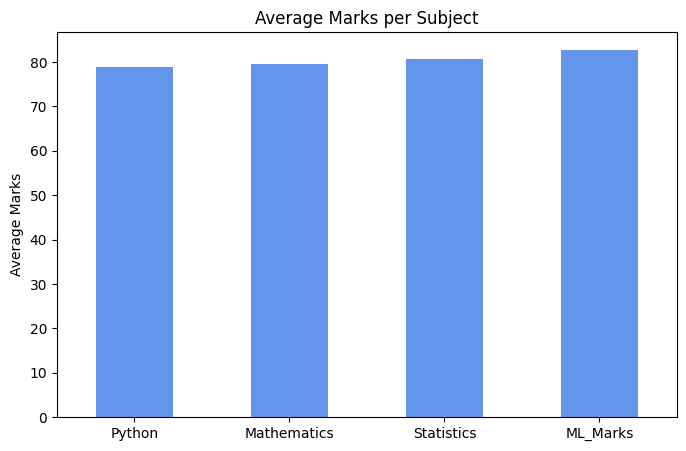

In [62]:
plt.figure(figsize=(8, 5))
subject_averages.plot(kind="bar", color="cornflowerblue")
plt.title("Average Marks per Subject")
plt.ylabel("Average Marks")
plt.xticks(rotation=0)
plt.show()

Bar chart: Top 5 students

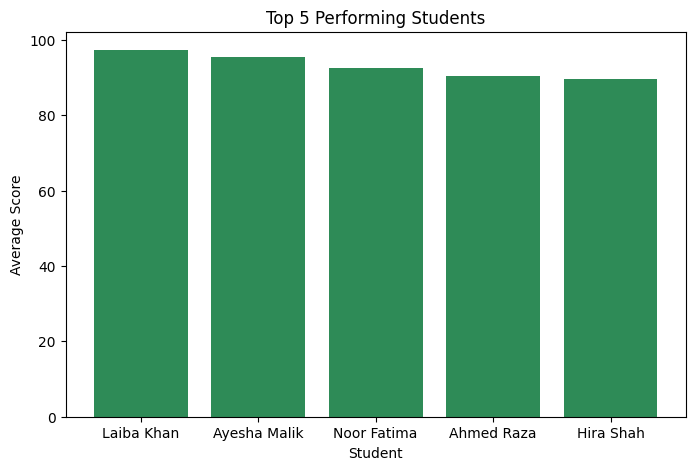

In [63]:
plt.figure(figsize=(8, 5))
plt.bar(top_5["Name"], top_5["Average_Score"], color="seagreen")
plt.title("Top 5 Performing Students")
plt.xlabel("Student")
plt.ylabel("Average Score")
plt.show()

Histogram: distribution of Average_Score

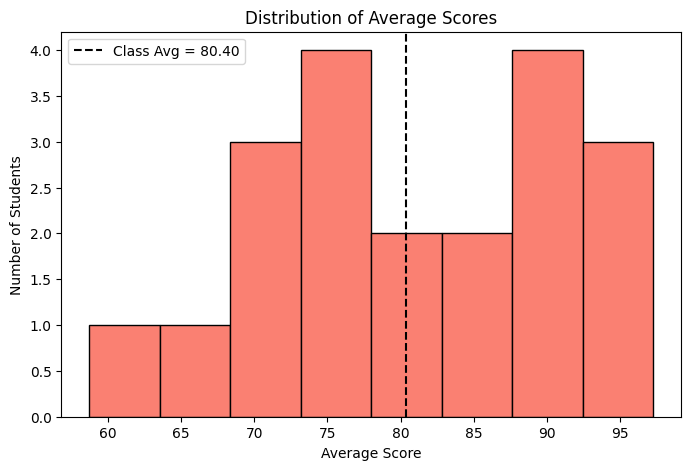

In [64]:
plt.figure(figsize=(8, 5))
plt.hist(df["Average_Score"], bins=8, color="salmon", edgecolor="black")
plt.axvline(overall_average, color="black", linestyle="--", label=f"Class Avg = {overall_average:.2f}")
plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

 Pie chart: needs improvement vs on-track

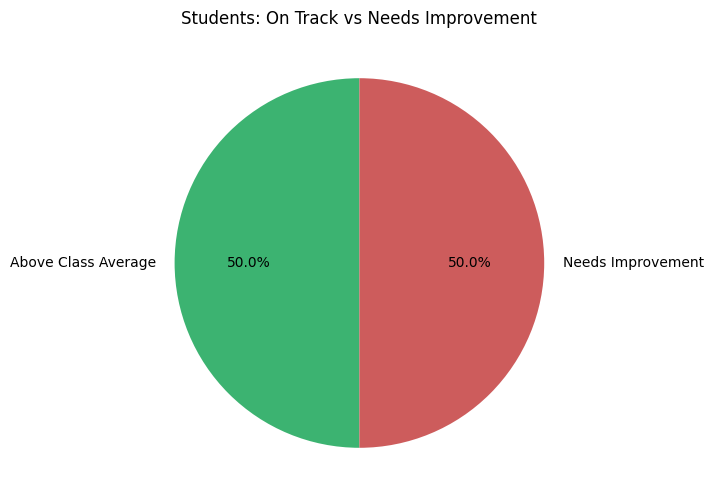

In [65]:
status_counts = pd.Series({
    "Above Class Average": len(df) - len(needs_improvement),
    "Needs Improvement": len(needs_improvement)
})

plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=90, colors=["mediumseagreen", "indianred"])
plt.title("Students: On Track vs Needs Improvement")
plt.show()